In [10]:
import numpy as np
import scipy.linalg
import scipy.signal
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [14]:
class CGM():
    def __init__(self, a, b, c, d, dt, beta, gamma, controller_penalty, target=83, base_insulin=10):
        # This is our target glucose measurement 
        self.target = target
        # This is the baseline amount of insulin
        self.base_insulin = base_insulin 
        # Our model will penalize the difference between the current state and these baselines

        # Define evolution matrices for AX + Bu
        A = np.array([[-a, -b], [d, -c]])
        B = np.array([[0], [1]])

        # Now we convert to a discrete system since we only sample every few minutes
        # see https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.cont2discrete.html#scipy.signal.cont2discrete
        discrete_system = scipy.signal.cont2discrete((A, B, np.eye(2), np.zeros((2,1))), dt, method='zoh')
        self.A = discrete_system[0]
        self.B = discrete_system[1]
        
		# beta and gamma are constants that weight how much we care about the rate of change in glucose and 
        # how close the glucose level is to the target
        self.Q = np.array([[beta*(a**2) + gamma, -beta*a*b],
                           [-beta*a*b, beta*(b**2)]])
        self.R = np.array([controller_penalty])
        self.K = self.fit()
    def fit(self):
        # Solves discrete algebraic riccati equations
        P = scipy.linalg.solve_discrete_are(self.A, self.B, self.Q, self.R)
        return np.linalg.inv(self.R + self.B.T @ P @ self.B) @ (self.B.T @ P @ self.A)
    def control(self, current_values):
        """Given the value observed by the CGM use the objective to apply optimal control"""
        # First we calculate the errors
        glucose, insulin = current_values
        x1 = glucose - self.target
        x2 = insulin - self.base_insulin
        xk = np.array([[x1], [x2]])
        u = -self.K @ xk
        # We can't deliver negative insulin, the indexing is because u is technically a matrix
        u = max(0.0, u[0][0] + self.base_insulin)
        return u

In [33]:
def simulate(t_steps, dt, starting, a, b, c, d, beta, gamma, controller_penalty, target=83, base_insulin=10):
    cgm = CGM(a, b, c, d, dt, beta, gamma, controller_penalty, target, base_insulin)
    def fun(t, x, u):
        xerr = x - np.array([target, base_insulin])
        uerr = u - base_insulin
        dxdt = np.array([[-a, -b], [d, -c]]) @ xerr + np.array([0, 1]) * uerr
        #Make sure we don't get negative insulin
        if x[1] <= 0 and dxdt[1] < 0:
            dxdt[1] = 0
        return dxdt
    current = starting
    t_hist = []
    y_hist = []
    for t in range(0, t_steps, dt):
        current[0] += np.random.randint(0, 5)
        u = cgm.control(current)
        sol = solve_ivp(fun=fun, t_span=(t, t+dt), y0=current, args=(u,))
        current = np.maximum(0, sol.y[:, -1])
        t_hist.append(sol.t)
        y_hist.append(sol.y)
    return np.concatenate(t_hist), np.concatenate(y_hist, axis=1)


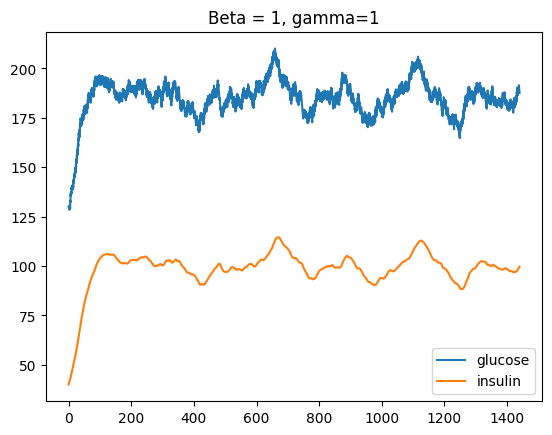

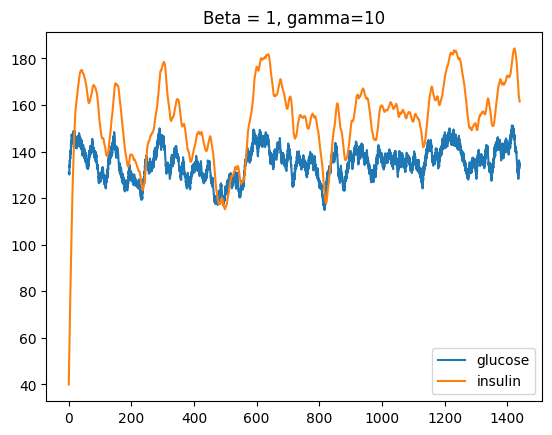

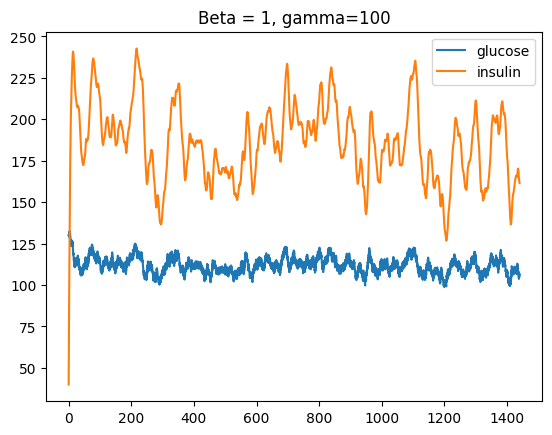

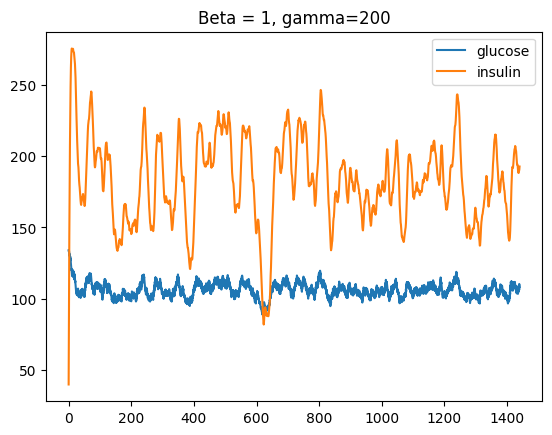

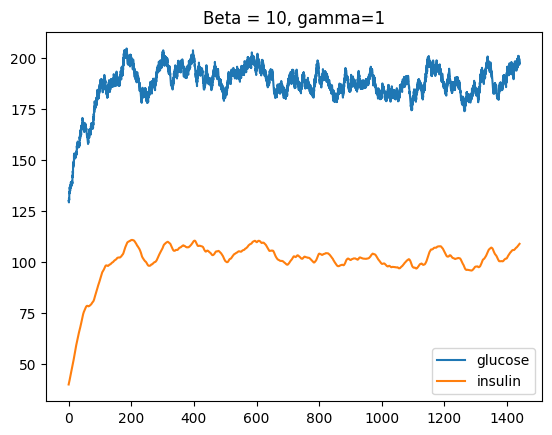

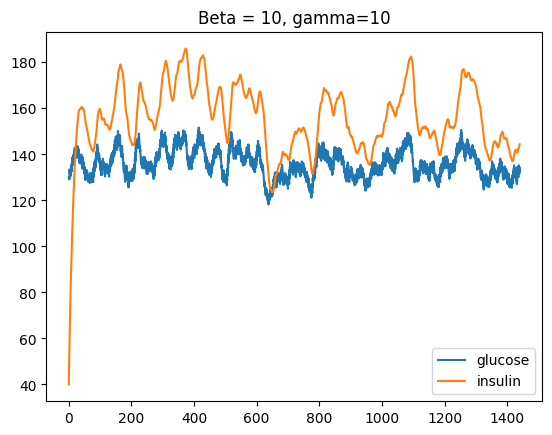

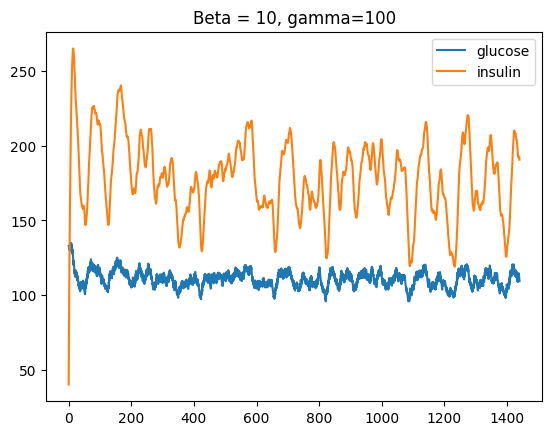

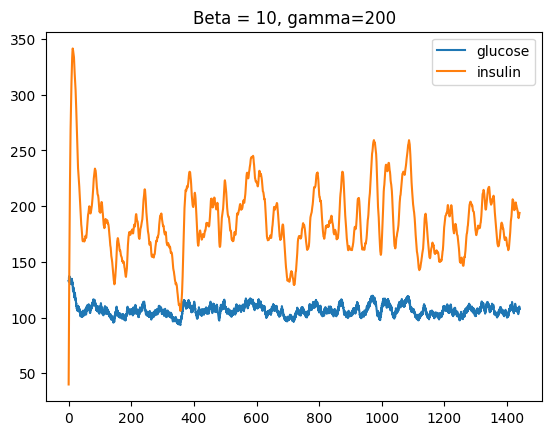

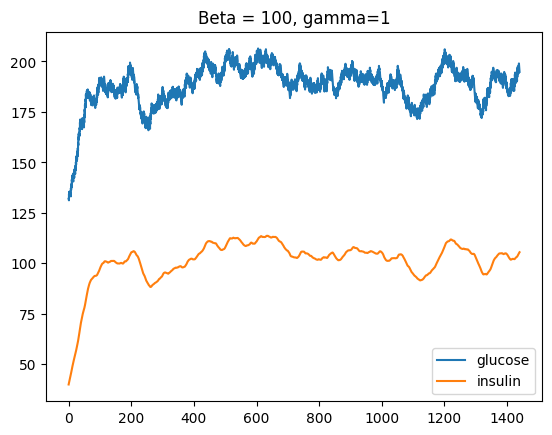

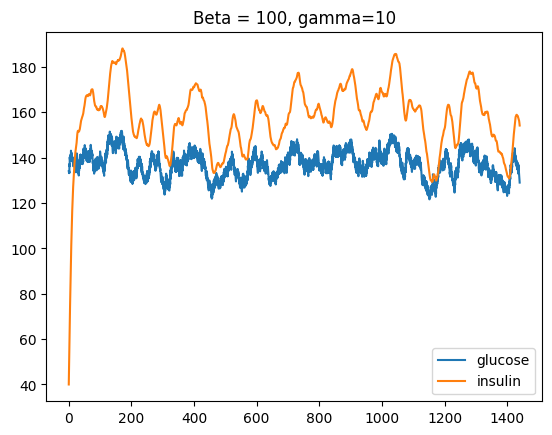

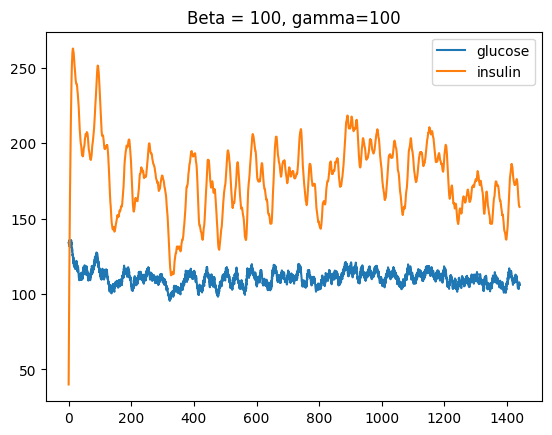

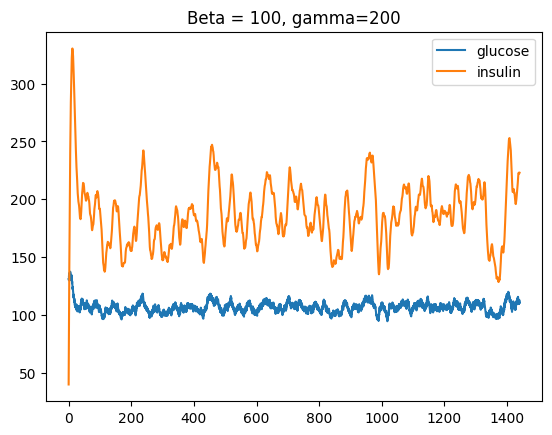

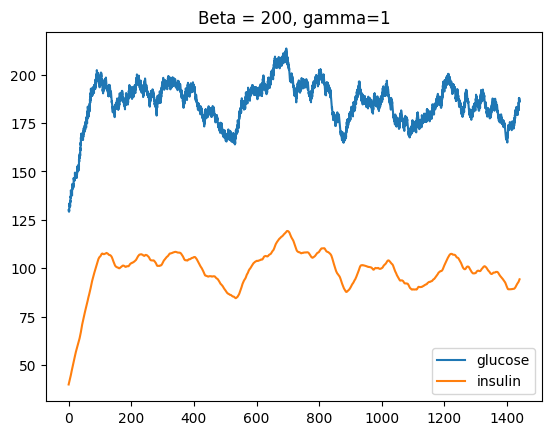

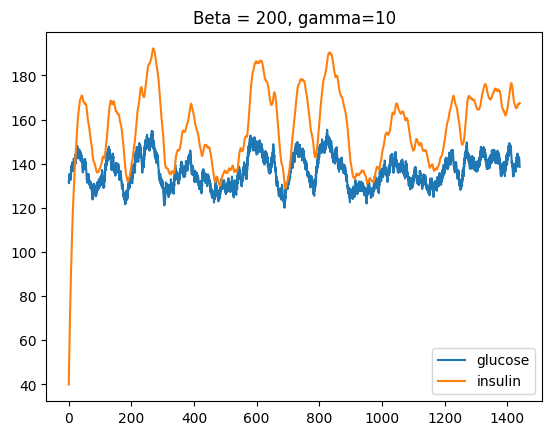

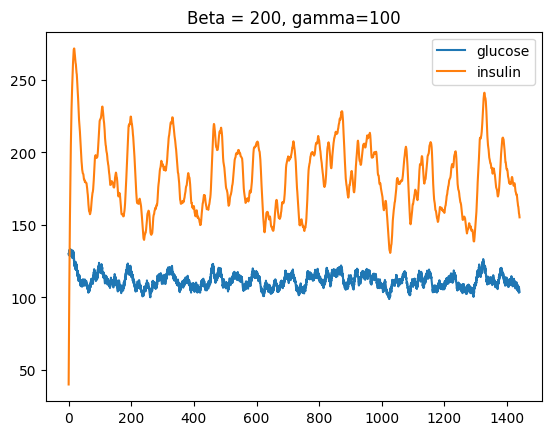

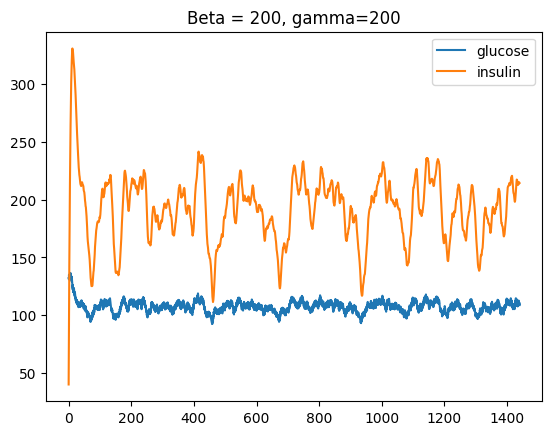

In [37]:
# higher beta means penalize glucose derivative more
# higher gamma means penalize glucose level more


betas = [1, 10, 100, 200]
gammas = [1, 10, 100, 200]

for beta in betas:
	for gamma in gammas:
		t, states = simulate(1440, 1, np.array([130, 40]), 0.01, 0.01, 0.05, 0.0, beta, gamma, 100)

		plt.plot(t, states[0], label='glucose')
		plt.plot(t, states[1], label='insulin')
		plt.legend()
		plt.title(f'Beta = {beta}, gamma={gamma}')
		plt.show()